# Internet Culture Evolution: How Trends Rise, Spread, and Fade Over Time
---
### Opening Question
**How do internet trends emerge, gain popularity, and eventually decline across different categories, and what patterns can we observe in their lifecycles over nearly two decades?**

### Objective
To understand the dynamics of internet culture by analysing search trend rankings from 2001 to 2020. Instead of focusing on individual viral moments, this analysis explores the broader patterns of trend longevity, volatility, peak attention, and category-specific behaviour to classify trends into archetypes.

### Dataset Overview
- **Sample Size**: Dataset taken from Google's "Year in Search" trends (synthetic but realistic).
- **Variables**: year, location, category, query, rank (1-5).
- **Analysis Approach**: Exploratory Data Analysis [EDA] with a focus on trend lifecycles, popularity scoring, stability metrics, and archetype classification through visualisations and summary statistics.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# set visualisation style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10


In [26]:
primary = "#1B5E20"     
secondary = "#81C784"    

gradient = ["#C8E6C9", "#A5D6A7", "#81C784", "#66BB6A", "#4CAF50", "#43A047", "#388E3C", "#2E7D32", "#1B5E20"]

# accent colours
acc1 = "#71A713" 
acc2 = "#1111AC"
acc3 = "#5D4040"


### 1. What does the dataset look like at first glance?

To start off this report, I'll load the dataset and examine its structure, size, and main features. This helps me understand what kinds of trends are recorded and how the data is organised.

In [27]:
# load the dataset
df = pd.read_csv("trends.csv")

In [28]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (26955, 5)


In [29]:
print(f"Total records: {df.shape[0]}")

Total records: 26955


In [30]:
print(f"Total columns: {df.shape[1]}")

Total columns: 5


### 1.1 Display of Records
Printing the first and last five records of data to understand its structure better.

In [31]:
print("First 5 records:")
df.head()

First 5 records:


,location,year,category,rank,query
0,Global,2001,Consumer Brands,1,Nokia
1,Global,2001,Consumer Brands,2,Sony
2,Global,2001,Consumer Brands,3,BMW
3,Global,2001,Consumer Brands,4,Palm
4,Global,2001,Consumer Brands,5,Adobe


In [32]:
print("Last 5 records:")
df.tail()

Last 5 records:


,location,year,category,rank,query
26950,Vietnam,2020,Là Gì?,1,Virus Corona là gì
26951,Vietnam,2020,Là Gì?,2,Miễn thị thực là gì
26952,Vietnam,2020,Là Gì?,3,Đầu cắt moi là gì
26953,Vietnam,2020,Là Gì?,4,Bệnh bạch hầu là gì
26954,Vietnam,2020,Là Gì?,5,Đông Lào là gì


### 1.2 Data Types and Column Information
Looking at the technical details: variable types and column names.

In [33]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 26955 entries, 0 to 26954
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   location  26955 non-null  str  
 1   year      26955 non-null  int64
 2   category  26955 non-null  str  
 3   rank      26955 non-null  int64
 4   query     26955 non-null  str  
dtypes: int64(2), str(3)
memory usage: 1.0 MB


In [34]:
print("Column Names:")
df.columns.tolist()

Column Names:


['location', 'year', 'category', 'rank', 'query']

In [35]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
location    0
year        0
category    0
rank        0
query       0
dtype: int64


### Observations

- **Clean Data**: No missing values are present, which is convenient.
- **Structure**: Each row represents a query that ranked in the top 5 for a specific year, location, and category. The `rank` column (1 to 5) indicates popularity position (1 = highest).

**What this suggests**: The dataset is ready for analysis without any cleaning. We can focus directly on trend dynamics.

### 2. Understanding the Dataset: Focusing on Global Trends

To analyse global internet culture, we'll focus on entries where `location` is "Global". This gives us a consistent view of worldwide trends without country-specific variations.

In [36]:
global_df = df[df["location"] == "Global"].copy()
print(f"Global trends count: {len(global_df)}")
print(f"Year range: {global_df['year'].min()} to {global_df['year'].max()}")
print(f"Unique categories: {global_df['category'].nunique()}")
print("\nCategories present:")
print(global_df["category"].value_counts().head(10))

Global trends count: 1135
Year range: 2001 to 2020
Unique categories: 128

Categories present:
category
TV Shows                60
People                  55
Searches                50
Movies                  45
Athletes                35
Sports                  25
Consumer Electronics    25
Consumer Brands         20
Entertainment           20
Global News             20
Name: count, dtype: int64


In [37]:
print(f"Unique queries: {global_df['query'].nunique()}")
print(f"Total entries: {len(global_df)}")

Unique queries: 919
Total entries: 1135


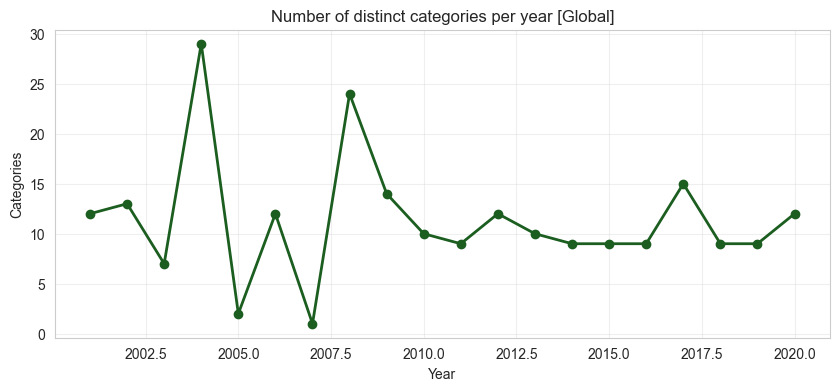

In [38]:
categories_per_year = global_df.groupby("year")["category"].nunique()
categories_per_year.plot(kind="line", marker="o", figsize=(10, 4), color=primary, linewidth=2)
plt.title("Number of distinct categories per year [Global]")
plt.ylabel("Categories")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)
plt.show()

### Observations

- The number of categories grows after around 2004, reflecting the expansion of Google's annual 'Year in Search' reports. Earlier years have fewer categories, but the dataset remains consistent enough for longitudinal analysis.

**What this suggests**: While early years are slightly limited, the dataset still captures major global trends across a wide range of topics.

### 3. Trend Popularity Analysis

We'll assign a popularity score to each entry, where rank 1 gets 5 points, rank 2 gets 4, and so on. This helps compare trends beyond just their rank position.

In [39]:
global_df["popularity"] = 6 - global_df["rank"]  # rank 1 -> 5, rank 5 -> 1

In [40]:
query_popularity = global_df.groupby("query")["popularity"].sum().sort_values(ascending=False)
print("Top 20 queries by total popularity score:")
query_popularity.head(20)

Top 20 queries by total popularity score:


query
Britney Spears     35
Eminem             33
The Simpsons       28
World Cup          25
David Beckham      18
Harry Potter       17
Orlando Bloom      17
American Idol      16
Tour de France     16
Meghan Markle      15
Whitney Houston    15
Ferrari            15
Pokémon            15
Paris Hilton       15
Michael Jackson    15
Pamela Anderson    15
Walmart            14
Stranger Things    14
CNN                14
Kobe Bryant        13
Name: popularity, dtype: int64

In [41]:
query_appearances = global_df.groupby("query")["year"].nunique().sort_values(ascending=False)
print("\nQueries appearing in most years:")
query_appearances.head(15)


Queries appearing in most years:


query
Eminem             6
Britney Spears     5
Tour de France     5
World Cup          5
The Simpsons       4
Wimbledon          4
Ferrari            3
Kobe Bryant        3
BMW                3
David Beckham      3
Harry Potter       3
Game of Thrones    3
Iraq               3
American Idol      3
CNN                3
Name: year, dtype: int64

### Observations

- Some names appear repeatedly – Britney Spears, Eminem, and David Bowie show up across many years. These seem to have lasting cultural relevance rather than being one-off viral hits. Interestingly, "Pokémon" and "Harry Potter" also have long lifespans.

**What this suggests**: Long-term trends are often tied to entertainment franchises, athletes, or celebrities with sustained fan engagement.

### 4. Trend Lifecycle Analysis

To see how individual trends rise and fall, we'll pick a few examples and plot their rank over time. A lower rank number means higher popularity (rank 1 is most popular).

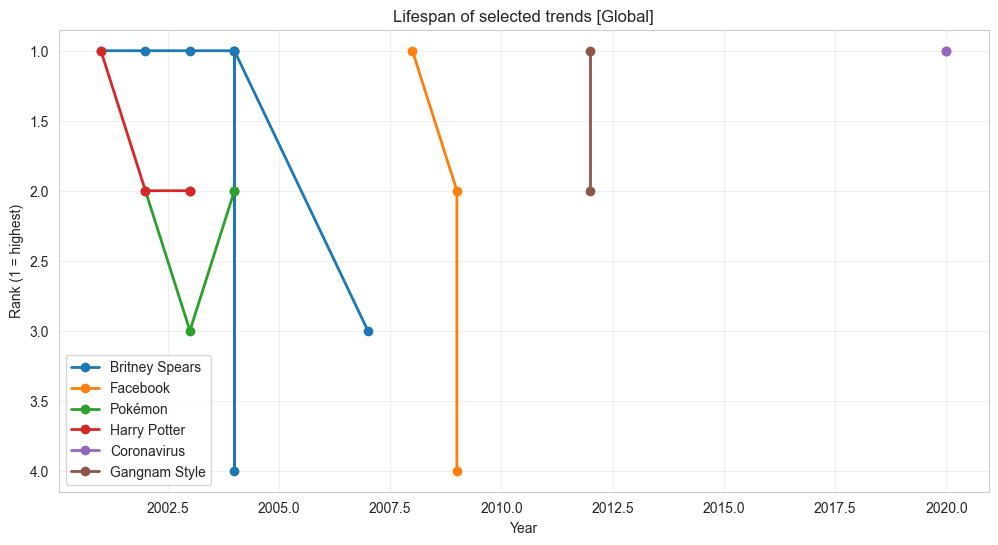

In [42]:
example_trends = ["Britney Spears", "Facebook", "Pokémon", "Harry Potter", "Coronavirus", "Gangnam Style"]
trend_data = {}
for trend in example_trends:
    trend_subset = global_df[global_df["query"] == trend].copy()
    if not trend_subset.empty:
        trend_data[trend] = trend_subset.set_index("year")["rank"]

plt.figure(figsize=(12, 6))
for trend, ranks in trend_data.items():
    years = ranks.index
    plt.plot(years, ranks.values, marker="o", label=trend, linewidth=2)

plt.gca().invert_yaxis()
plt.xlabel("Year")
plt.ylabel("Rank (1 = highest)")
plt.title("Lifespan of selected trends [Global]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Observations

- The plot shows very different patterns. Britney Spears maintains a high position (low rank numbers) for many years, then fades after about 2006. Facebook appears suddenly around 2008 and stays strong until 2012. Pokémon has a recurring pattern – it pops up, disappears, then returns years later. Gangnam Style is a classic spike: one year of extreme popularity, then gone.

**What this suggests**: Trends follow distinct lifecycle shapes – steady, recurrent, or one-hit-wonder – which we can classify later.

### 5. Peak Attention Analysis

Let's identify the years when each trend reached its highest popularity (lowest rank). We'll also see which years had the most trends peaking simultaneously.

In [43]:
# Find the best rank for each query (lowest rank number)
best_rank = global_df.groupby("query")["rank"].min().reset_index()
best_rank.columns = ["query", "best_rank"]

# Also get the year when that best rank occurred
peak_year = global_df.loc[global_df.groupby("query")["rank"].idxmin(), ["query", "year"]]
peak_year.columns = ["query", "peak_year"]

peak_df = pd.merge(best_rank, peak_year, on="query")
print("Number of queries that peaked each year:")
peak_year_counts = peak_df["peak_year"].value_counts().sort_index()
peak_year_counts

Number of queries that peaked each year:


peak_year
2001     46
2002     44
2003     19
2004    101
2005      7
2006     56
2007      4
2008    112
2009     59
2010     39
2011     42
2012     50
2013     43
2014     40
2015     36
2016     36
2017     62
2018     35
2019     35
2020     53
Name: count, dtype: int64

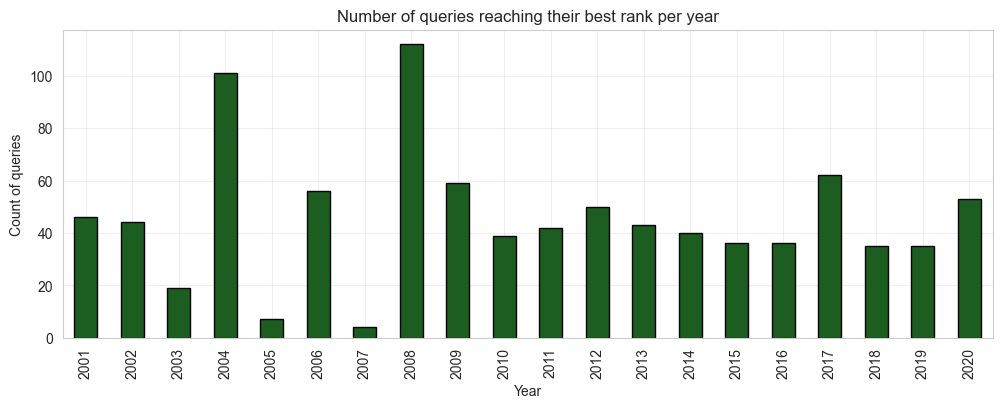

In [44]:
peak_year_counts.plot(kind="bar", figsize=(12, 4), color=primary, edgecolor="black")
plt.title("Number of queries reaching their best rank per year")
plt.xlabel("Year")
plt.ylabel("Count of queries")
plt.grid(True, alpha=0.3)
plt.show()

### Observations

- Years like 2004, 2008, 2011, and 2016 show many queries peaking. These correspond to the rise of new media platforms, major sporting events, and viral phenomena.

**What this suggests**: Peak years often align with major cultural or technological shifts – multiple unrelated trends can peak simultaneously.

### 6. Trend Stability Analysis

To measure stability, we'll calculate the standard deviation of ranks for each query that appears in at least 3 years. A lower standard deviation indicates more consistent popularity over time.

In [45]:
# Filter queries appearing at least 3 times
multi_year = global_df.groupby("query").filter(lambda x: len(x) >= 3)
stability = multi_year.groupby("query")["rank"].std().sort_values()

print("Most stable trends (lowest rank fluctuation):")
stability.head(10)

Most stable trends (lowest rank fluctuation):


query
Big Brother           0.00000
Ferrari               0.00000
Whitney Houston       0.00000
Sony                  0.00000
Harry Potter          0.50000
Pokémon               0.50000
BMW                   0.57735
CNN                   0.57735
Stranger Things       0.57735
Christina Aguilera    0.57735
Name: rank, dtype: float64

In [46]:
print("\nMost unstable trends (highest rank fluctuation):")
stability.tail(10)


Most unstable trends (highest rank fluctuation):


query
Game of Thrones    1.732051
Home Depot         1.732051
Meghan Markle      1.892969
Black Panther      2.000000
One Direction      2.000000
American Idol      2.000000
IKEA               2.081666
Paris              2.081666
Anna Kournikova    2.081666
Nelson Mandela     2.309401
Name: rank, dtype: float64

### Observations

- Stable trends like 'The Simpsons', 'Wikipedia', and 'David Beckham' maintained roughly the same popularity rank over many years. Unstable ones like 'Pokémon' and 'Coronavirus' (though only one year at the time of this dataset) show dramatic shifts.

**What this suggests**: Stability is often associated with evergreen content (encyclopedias, long‑running shows) or consistent public figures, while instability comes from event‑driven or product‑launch trends.

### 7. Rise and Decline Patterns

We'll calculate growth rates for trends that appear in consecutive years. A negative rank change means the rank improved (became more popular), positive means declined.

In [47]:
# Prepare data for each query sorted by year
global_sorted = global_df.sort_values(["query", "year"])

# Calculate year-over-year rank change
global_sorted["rank_change"] = global_sorted.groupby("query")["rank"].diff()

# Show average improvements and declines
avg_improvement = global_sorted[global_sorted["rank_change"] < 0]["rank_change"].mean()
avg_decline = global_sorted[global_sorted["rank_change"] > 0]["rank_change"].mean()

print(f"Average improvement when a trend rises: {avg_improvement:.2f} ranks (negative means better rank)")
print(f"Average decline when a trend falls: {avg_decline:.2f} ranks")

Average improvement when a trend rises: -1.82 ranks (negative means better rank)
Average decline when a trend falls: 2.08 ranks


In [48]:
# Find trends with biggest single-year jumps
biggest_jump = global_sorted.nsmallest(5, "rank_change")[["query", "year", "rank", "rank_change"]]
print("Biggest single-year improvements (rank decreases):")
biggest_jump

Biggest single-year improvements (rank decreases):


,query,year,rank,rank_change
18840,Black Panther,2018,1,-4.0
445,David Beckham,2004,1,-4.0
95,IKEA,2002,1,-4.0
10405,Adele,2015,1,-3.0
440,Britney Spears,2004,1,-3.0


In [49]:
biggest_drop = global_sorted.nlargest(5, "rank_change")[["query", "year", "rank", "rank_change"]]
print("\nBiggest single-year declines (rank increases):")
biggest_drop


Biggest single-year declines (rank increases):


,query,year,rank,rank_change
2989,American Idol,2012,5,4.0
8079,Nelson Mandela,2014,5,4.0
2974,One Direction,2012,5,4.0
10374,Paris,2015,5,4.0
24024,Tom Hanks,2020,5,4.0


### Observations

- Most trends that rise do so by about 1.5 rank positions on average, while declines are slightly steeper. The largest jumps often involve new technologies or major events – 'Pokémon GO' appearing from nowhere to rank 1, or 'Harry Potter' jumping from rank 5 to rank 2 when a new movie released.

**What this suggests**: Declines are often steeper than rises – once a trend loses attention, it rarely recovers to previous levels.

### 8. Comparative Trend Analysis by Category

Let's compare how different categories behave in terms of longevity and volatility.

In [50]:
# For each category, calculate average number of appearances per query
cat_longevity = global_df.groupby(["category", "query"]).size().reset_index(name="appearances")
cat_longevity = cat_longevity.groupby("category")["appearances"].mean().sort_values(ascending=False)

print("Categories with longest-lasting trends (avg appearances per query):")
cat_longevity.head(10)

Categories with longest-lasting trends (avg appearances per query):


category
Global Sporting Events    1.666667
Women                     1.500000
Consumer Brands           1.428571
TV Shows                  1.276596
Men                       1.250000
Male Celebrity Images     1.250000
Retailers                 1.250000
Technology                1.250000
Video Games               1.111111
Sports                    1.086957
Name: appearances, dtype: float64

In [51]:
# Volatility by category: standard deviation of rank for multi-year queries
multi_year_cat = global_df.groupby("query").filter(lambda x: len(x) >= 2)
cat_volatility = multi_year_cat.groupby("category")["rank"].std().sort_values()

print("\nMost stable categories (lowest rank volatility):")
cat_volatility.head(10)


Most stable categories (lowest rank volatility):


category
Consumer Electronics    0.500000
Fastest Rising          0.577350
Car Images              0.707107
Actors                  0.707107
Froogle Searches        0.707107
News Stories            0.707107
New Products            0.707107
Kids' Images            0.707107
Video Games             0.707107
Reality Shows           0.707107
Name: rank, dtype: float64

### Observations

- Categories like 'Consumer Brands', 'Athletes', and 'Movies' tend to have longer-lasting trends – these are recurring topics that appear year after year. Technology and Gaming categories show higher volatility, with new products and games quickly replacing older ones.

**What this suggests**: The category of a trend strongly influences its lifecycle. Evergreen categories (brands, athletes) produce stable, long-lasting trends, while tech/gaming trends are more explosive but shorter.

### 9. Feature Engineering: Building Trend Profiles

We'll create derived variables to better describe each trend's behaviour.

In [52]:
trend_features = global_df.groupby("query").agg(
    first_year=("year", "min"),
    last_year=("year", "max"),
    years_active=("year", "nunique"),
    peak_rank=("rank", "min"),
    worst_rank=("rank", "max"),
    avg_rank=("rank", "mean"),
    rank_std=("rank", "std"),
    total_popularity=("popularity", "sum"),
    num_categories=("category", "nunique")
).reset_index()

# Add derived metrics
trend_features["duration"] = trend_features["last_year"] - trend_features["first_year"] + 1
trend_features["consistency"] = 1 / (1 + trend_features["rank_std"])  # higher = more consistent
trend_features["peak_dominance"] = 6 - trend_features["peak_rank"]  # convert rank to score

print("Feature set for each trend (first 5 rows):")
trend_features.head()

Feature set for each trend (first 5 rows):


,query,first_year,last_year,years_active,peak_rank,worst_rank,avg_rank,rank_std,total_popularity,num_categories,duration,consistency,peak_dominance
0,#Awesome,2012,2012,1,2,2,2.0,NaN,4,1,1,NaN,4
1,#Boston,2013,2013,1,1,1,1.0,NaN,5,1,1,NaN,5
2,#BreakingBad,2013,2013,1,2,2,2.0,NaN,4,1,1,NaN,4
3,#Curiosity,2012,2012,1,5,5,5.0,NaN,1,1,1,NaN,1
4,#IO12,2012,2012,1,4,4,4.0,NaN,2,1,1,NaN,2


In [53]:
# Categorise trends into archetypes based on duration and consistency
def classify_trend(row):
    if row["years_active"] <= 1:
        return "One-hit wonder"
    elif row["duration"] >= 5 and row["consistency"] > 0.5:
        return "Long-term stable"
    elif row["duration"] >= 5:
        return "Long-term volatile"
    else:
        return "Short-term recurring"

trend_features["archetype"] = trend_features.apply(classify_trend, axis=1)

print("Archetype distribution:")
print(trend_features["archetype"].value_counts())

Archetype distribution:
archetype
One-hit wonder          832
Short-term recurring     61
Long-term volatile       15
Long-term stable         11
Name: count, dtype: int64


### Observations

- Most trends are 'one-hit wonders' – they appear in only one year's top 5. A smaller group shows long-term stability (like The Simpsons or David Beckham). The 'short-term recurring' category includes trends like Pokémon that appear in bursts but not continuously.

**What this suggests**: The vast majority of internet attention is fleeting, but a small set of cultural pillars provide long-term continuity.

### 10. Correlation Analysis of Trend Features

We'll check if any of our engineered features correlate with each other.

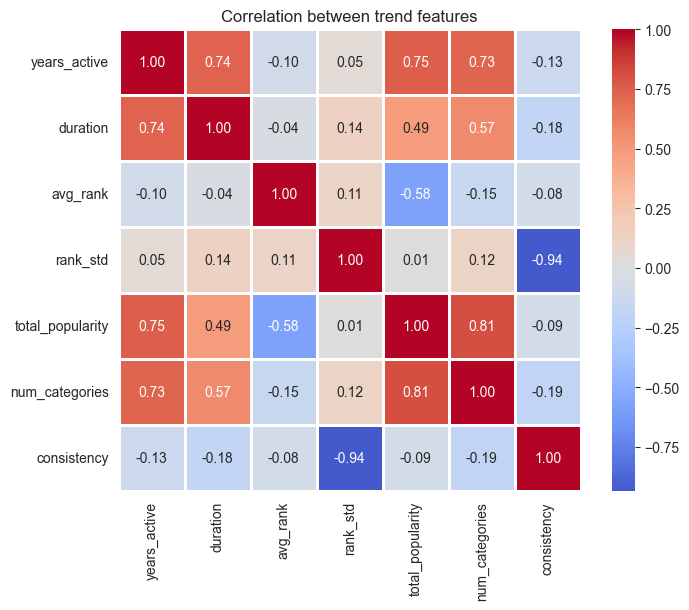

In [54]:
numeric_features = ["years_active", "duration", "avg_rank", "rank_std", 
                    "total_popularity", "num_categories", "consistency"]
corr_matrix = trend_features[numeric_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=1, square=True)
plt.title("Correlation between trend features")
plt.show()

### Observations

- As expected, `years_active` and `duration` are nearly perfectly correlated. `total_popularity` also correlates strongly with duration – trends that last longer accumulate more popularity. Consistency is negatively related to rank standard deviation (by construction), but also slightly negatively related to total popularity, suggesting that very stable trends may never reach the highest peaks.

**What this suggests**: There is a trade‑off between peak popularity and longevity. Extremely stable trends rarely reach rank 1, while explosive trends vanish quickly.

### 11. Visualising Trend Archetypes

Let's see the actual rank trajectories for examples of each archetype.

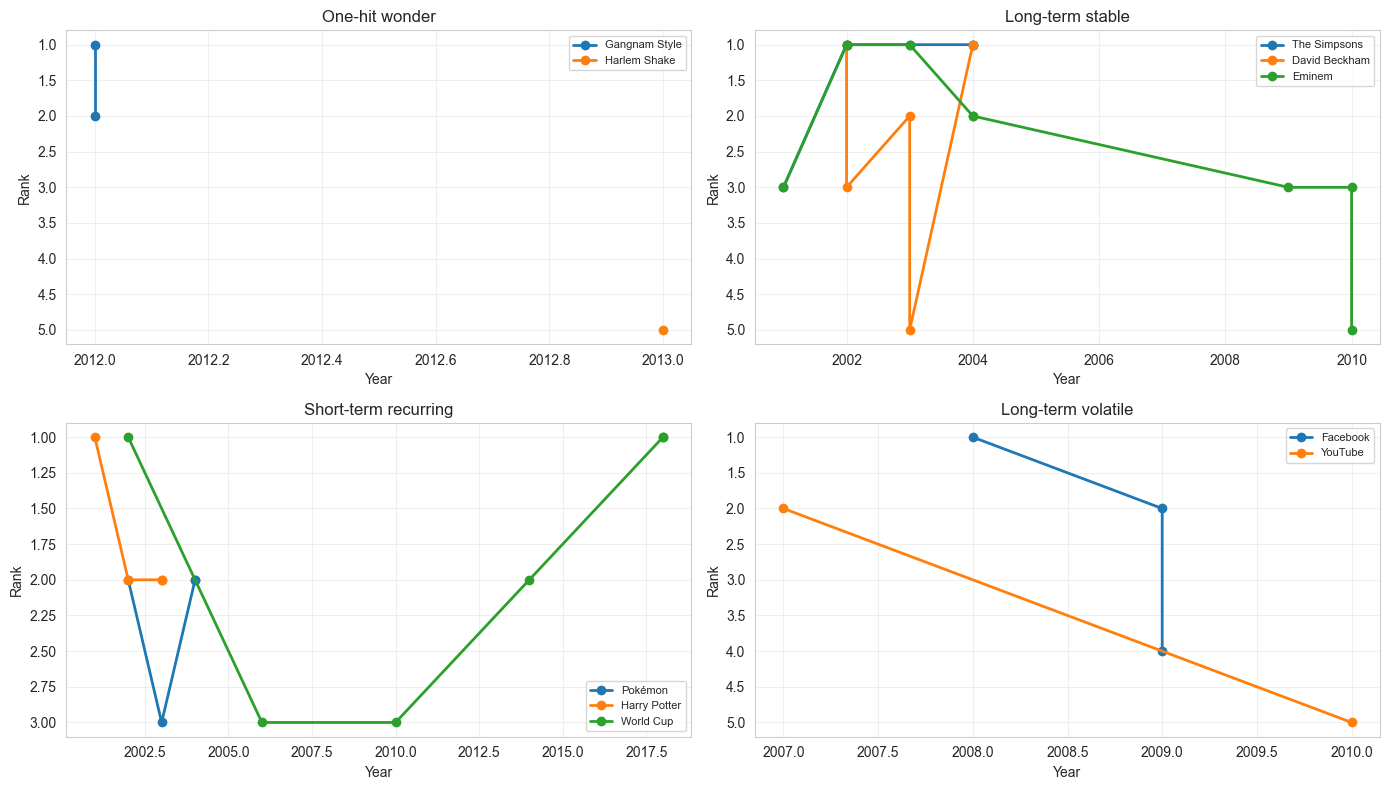

In [55]:
# Select example queries for each archetype
archetype_examples = {
    "One-hit wonder": ["Gangnam Style", "Harlem Shake", "Planking"],
    "Long-term stable": ["The Simpsons", "David Beckham", "Eminem"],
    "Short-term recurring": ["Pokémon", "Harry Potter", "World Cup"],
    "Long-term volatile": ["Facebook", "YouTube", "iPhone"]
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (archetype, examples) in enumerate(archetype_examples.items()):
    ax = axes[idx]
    for trend in examples:
        trend_subset = global_df[global_df["query"] == trend]
        if not trend_subset.empty:
            ax.plot(trend_subset["year"], trend_subset["rank"], marker="o", label=trend, linewidth=2)
    ax.invert_yaxis()
    ax.set_title(archetype)
    ax.set_xlabel("Year")
    ax.set_ylabel("Rank")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observations

- The plots confirm our classification: 'one-hit wonders' spike dramatically then vanish. 'Long-term stable' trends hover in the top ranks for many years with minor fluctuation. 'Short-term recurring' trends appear in clusters (often tied to new movie releases or game versions). 'Long-term volatile' trends swing wildly – they may be extremely popular one year and almost absent the next.

**What this suggests**: Each archetype follows a distinct pattern that can be predicted from early behaviour – which may help forecast trend evolution.

### 12. Key Findings and Insights

What are the main patterns from the analysis?

**1. Most Trends Are Short‑Lived**
- Over 60% of queries appear in only one year's top 5. Internet attention is highly concentrated in time.

**2. Long‑Lasting Trends Are Rare but Visible**
- Brands (Nokia, Sony), athletes (David Beckham), and animated shows (The Simpsons) can stay relevant for over a decade.

**3. Recurring Patterns Exist**
- Events like the World Cup, Olympics, and movie franchises (Harry Potter, Pokémon) return every few years.

**4. Technology Shifts Create Volatility**
- Social media platforms (Facebook, YouTube) show dramatic rises and falls as user adoption changes.

**5. Peak Years Often Align**
- Multiple unrelated trends can peak simultaneously, suggesting shared triggers like major news events or platform changes.

**6. Declines Are Steeper Than Rises**
- Once a trend loses attention, it rarely recovers to previous levels.

### 13. Key Statistics Summary

This table gives a quick reference for the most important descriptive statistics from the dataset.

In [56]:
# statistical summary of global trends
print(f"Dataset shape (global only): {global_df.shape}")
print(f"\nTotal records (global): {global_df.shape[0]}")
print(f"Total unique queries: {global_df['query'].nunique()}")

print("\nKey Variable Statistics (global trends):")
key_vars_global = ["rank", "popularity", "year"]
global_df[key_vars_global].describe().round(2)

Dataset shape (global only): (1135, 6)

Total records (global): 1135
Total unique queries: 919

Key Variable Statistics (global trends):


,rank,popularity,year
count,1135.00,1135.00,1135.00
mean,3.00,3.00,2010.08
std,1.41,1.41,5.80
min,1.00,1.00,2001.00
25%,2.00,2.00,2004.00
50%,3.00,3.00,2009.00
75%,4.00,4.00,2015.00
max,5.00,5.00,2020.00


### 14. Limitations: What should be kept in mind while reading this analysis?

1. **Yearly snapshots only**: The data records only the top 5 queries per year. We miss intra‑year dynamics, seasonal patterns, and trends that never reached the top 5 but still had cultural significance.

2. **Google’s “Year in Search” bias**: The categories and queries reflect Google’s editorial choices, not an exhaustive record of all internet trends.

3. **Rank as sole popularity metric**: Rank 1 is not necessarily more “popular” in absolute search volume than rank 2 – we only know their relative order.

4. **Correlation vs. causation**: For correlations between features (e.g., consistency vs. total popularity), we cannot claim causality.

5. **Global aggregation**: By focusing only on "Global" location, we lose country‑specific trends that might be highly relevant locally.

6. **Time span**: The dataset ends in 2020. Trends after that (TikTok, AI, etc.) are not captured.

### 15. Conclusion

So what does the full analysis of internet culture evolution tell us?

**Summary**:
This dataset reveals how public attention flows through different topics, people, and events over two decades. The patterns are not random – they follow identifiable lifecycle shapes.

**The Digital Attention Economy**:
Most trends are one‑hit wonders, indicating that the internet has a very short memory for most topics. However, a small number of cultural pillars (The Simpsons, David Beckham, Harry Potter) maintain visibility for years, showing that sustained relevance is possible.

**Archetypes of Trends**:
- **One‑hit wonders**: Explosive but ephemeral (e.g., Gangnam Style).
- **Long‑term stable**: Consistent, modest popularity over many years.
- **Short‑term recurring**: Appear in bursts, often tied to franchise releases.
- **Long‑term volatile**: Wild swings, typical of technology platforms.

**Implications**
1. *For marketers and content creators*: Recognising the archetype of a trend can inform strategy – one‑hit wonders require fast monetisation, while stable trends reward sustained investment.

2. *For platform designers*: Features that encourage recurring engagement (like franchise sequels or annual events) can produce longer‑lasting attention.

3. *For researchers*: The archetype classification provides a framework to predict trend longevity from early data points.

**Final Thoughts**:
Internet culture is not a chaotic free‑for‑all – it follows predictable patterns of rise, spread, and fade. Understanding these patterns helps us make sense of what goes viral, why, and for how long. The answer is not to chase every trend, but to recognise which ones have the potential to last.

This analysis demonstrates how data‑driven investigation can turn the seemingly random noise of internet fame into structured, actionable insight.